In [1]:
# importing all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Consider Sales Dataset and analyse it in proper way.
## Expectation:-
 Need a clarity on who is spending more money for shopping incase of gender, age, _group,state,Occupation,Product_category,martial_status.

In [2]:
sales=pd.read_csv(r"C:\Users\Vinay Babu\Downloads\sales_data (4).csv",encoding='latin1')

In [3]:
sales.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.3 MB


In [5]:
# Checking the number of rowa and columns
sales.shape

(11251, 15)

In [18]:
sales.insta

AttributeError: 'DataFrame' object has no attribute 'insta'

In [6]:
# Dropping Unwanted columns
sales.drop(['Status','unnamed1'],axis=1,inplace=True)

In [7]:
sales.dropna(inplace=True)

In [8]:
# changing the values of gender form M --> Male and F -->
sales['gender']=sales['Gender'].map({'M':'Male','F':'Female'})
sales.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,gender
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,Female
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,Female
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,Female
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,Male
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,Male


In [9]:
sales['Amount'].isna().sum()


np.int64(0)

In [10]:
sales['Marital_Status']=sales['Marital_Status'].map({0:'Single',1:'Married'})
sales.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,gender
0,1002903,Sanskriti,P00125942,F,26-35,28,Single,Maharashtra,Western,Healthcare,Auto,1,23952.0,Female
1,1000732,Kartik,P00110942,F,26-35,35,Married,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,Female
2,1001990,Bindu,P00118542,F,26-35,35,Married,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,Female
3,1001425,Sudevi,P00237842,M,0-17,16,Single,Karnataka,Southern,Construction,Auto,2,23912.0,Male
4,1000588,Joni,P00057942,M,26-35,28,Married,Gujarat,Western,Food Processing,Auto,2,23877.0,Male


In [11]:
sales['State'].unique()

<StringArray>
[     'Maharashtra',   'Andhra Pradesh',    'Uttar Pradesh',
        'Karnataka',          'Gujarat', 'Himachal Pradesh',
            'Delhi',        'Jharkhand',           'Kerala',
          'Haryana',   'Madhya Pradesh',            'Bihar',
        'Rajasthan',      'Uttarakhand',        'Telangana',
           'Punjab']
Length: 16, dtype: str

In [12]:
sales.duplicated().sum()
sales.drop_duplicates(inplace=True)

In [13]:
def label(a):
    for i in a.containers:
        a.bar_label(i)

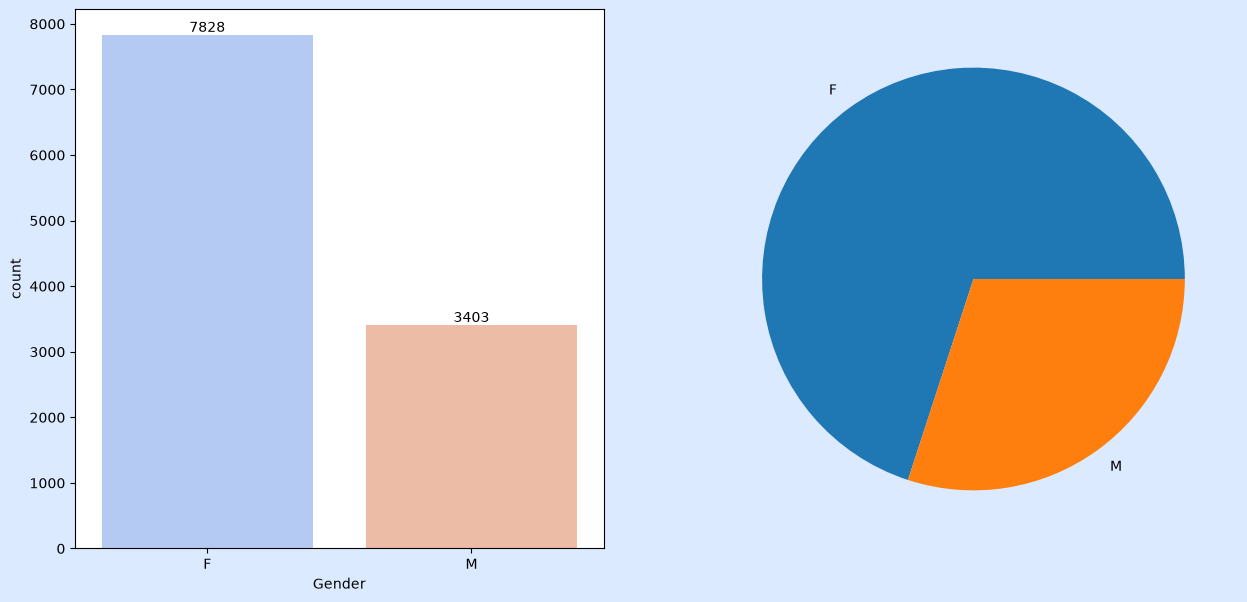

In [14]:
fig,axes=plt.subplots(nrows=1,ncols=2,facecolor='#DBEAFE',figsize=(15,7))
c_g=sns.countplot(x='Gender',data=sales,hue='Gender',palette='coolwarm',ax=axes[0])
label(c_g)
###########################################################
gender_gr=sales.groupby('Gender')['Amount'].sum()
gender_gr=pd.DataFrame(gender_gr)
plt.pie(gender_gr['Amount'],labels=gender_gr.index)
plt.show()


In [15]:
# Who is spending more money incase of gender?
gender_gr=sales.groupby('Gender')['Amount'].sum()

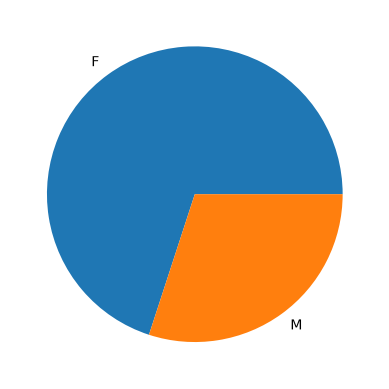

<module 'matplotlib.pyplot' from 'c:\\Users\\Vinay Babu\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\matplotlib\\pyplot.py'>

In [16]:
gender_gr=pd.DataFrame(gender_gr)
plt.pie(gender_gr['Amount'],labels=gender_gr.index)
plt.show()
plt

Females are spending more money in case shopping.

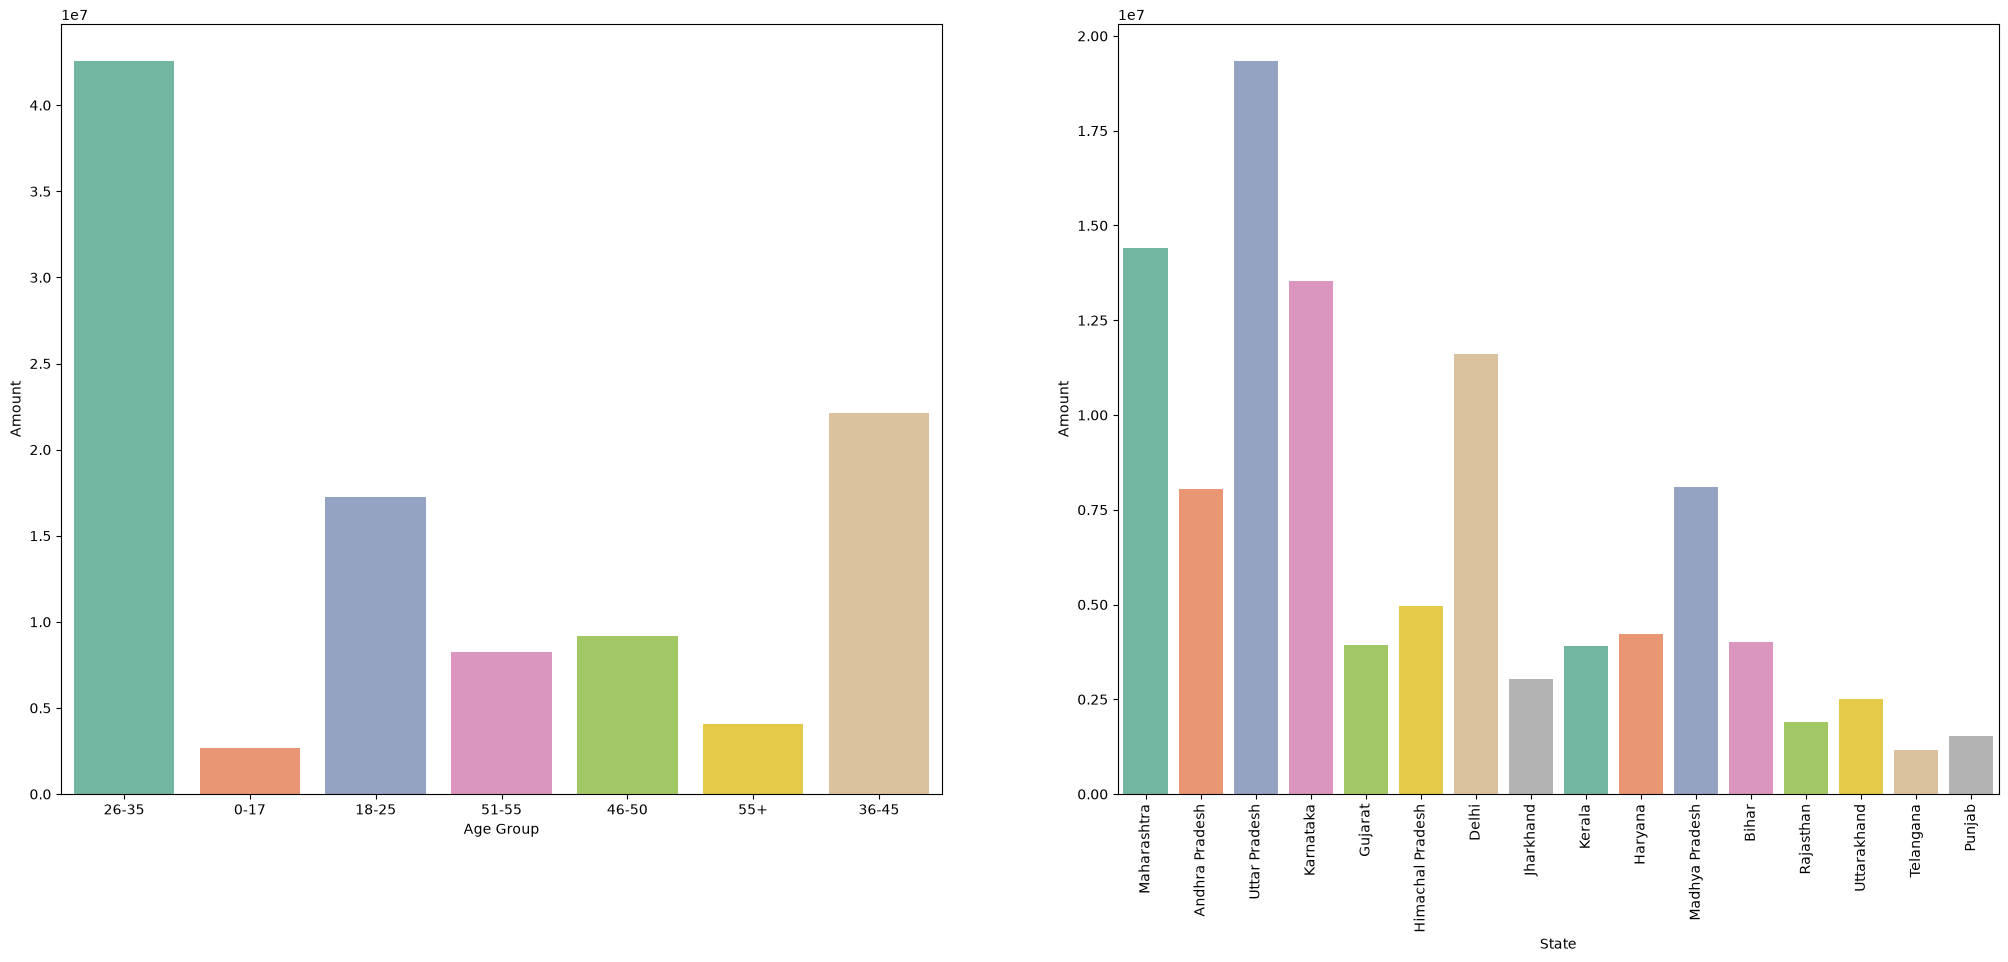

In [17]:
fig_1,axes=plt.subplots(ncols=2,nrows=1,figsize=(25,10))
sns.barplot(x='Age Group',y='Amount',data=sales,errorbar=None,hue='Age Group',estimator='sum',palette='Set2',ax=axes[0])
sns.barplot(x='State',y='Amount',data=sales,errorbar=None,hue='State',estimator='sum',palette='Set2',ax=axes[1])
plt.xticks(rotation=90)
plt.show()

The peopel between age group 26-27 from Uttar Pradesh , Maharashtra and karnataka are spending more money on shopping